In [18]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()
Pkg.precompile()
include("../src/usadel_core.jl")
using Plots
using SparseArrays
using LinearAlgebra

  Activating project at `~/dev/julia/usadel_1D`


In [19]:
#parameters and setup
Dn  = 2.0
Ds  = 2.0
ξn  = sqrt(Dn / 2.0) 
ξs  = sqrt(Ds / 2.0) 
Ln  = 20.0             
Ls  = 10.0             
dx  = 0.1              
Γin = 1e-3             


0.001

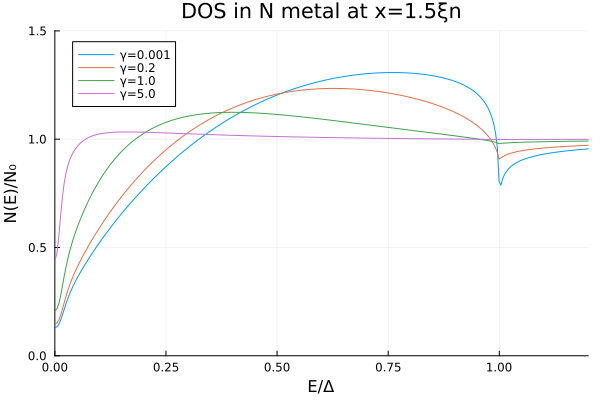

In [20]:

energies=collect(range(0.001,1.2,length=300))

γ_vals = [0.001, 0.2, 1.0, 5.0]

plt = Plots.plot(xlabel="E/Δ", ylabel="N(E)/N₀",
           title="DOS in N metal at x=1.5ξn",
           ylims=(0, 1.5), xlims=(0, 1.2),
           legend=:topleft, lw=2)

for γ in γ_vals
    σs = 1.0
    σn = γ #* ξn / ξs    # from γ = σn*ξs/σs*ξn
    p_γ = setup_simulation(Ln, Ls, dx, 0.0, Γin, σn, σs, Dn, Ds)
    dos, idx = compute_DOS(energies, p_γ, x_eval)
    plot!(plt, energies, dos, label="γ=$γ")
end

display(plt)

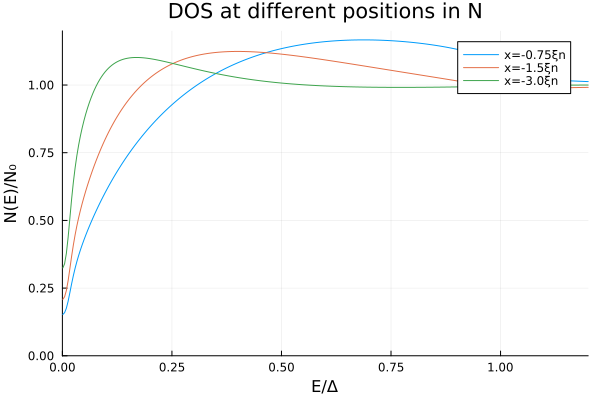

In [21]:
x_positions = [-0.75, -1.5, -3.0]

plt4 = plot(xlabel="E/Δ", ylabel="N(E)/N₀",
            title="DOS at different positions in N",
            ylims=(0, 1.2), xlims=(0, 1.2),
            legend=:topright, lw=2)

p_fig4 = setup_simulation(Ln, Ls, dx, 0.0, Γin, 1.0, 1.0, Dn, Ds)

for x in x_positions
    dos, _ = compute_DOS(energies, p_fig4, x)
    plot!(plt4, energies, dos, label="x=$(x)ξn")
end

display(plt4)

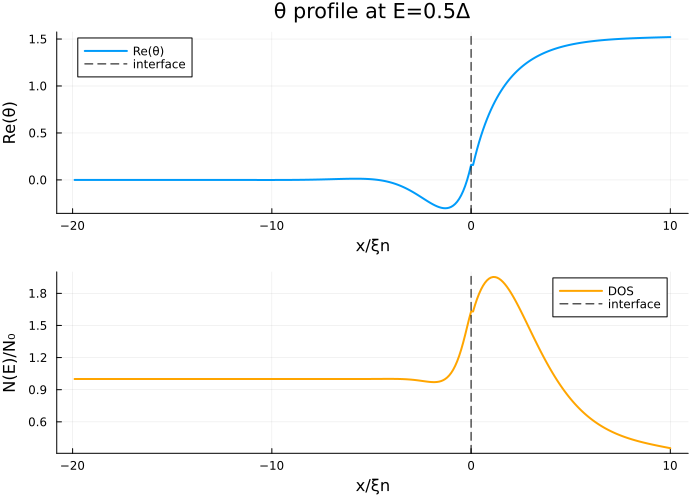

In [22]:

x_axis = [(i - p.i0L) * p.dx for i in 1:p.N]   # x=0 at interface

p1 = plot(x_axis, real.(theta),
          xlabel="x/ξn", ylabel="Re(θ)",
          title="θ profile at E=0.5Δ",
          label="Re(θ)", lw=2)

p2 = plot(x_axis, abs.(real.(cos.(theta))),
          xlabel="x/ξn", ylabel="N(E)/N₀",
          label="DOS", lw=2, color=:orange)

vline!(p1, [0.0], linestyle=:dash, color=:black, label="interface")
vline!(p2, [0.0], linestyle=:dash, color=:black, label="interface")

plot(p1, p2, layout=(2,1), size=(700,500))